In [4]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from hurst import compute_Hc
from arch.unitroot import VarianceRatio
from sklearn.linear_model import LinearRegression

ROUND_NUM = 5
BASE = 'round5'
DAYS = ['2', '3', '4']

price_rows = []
offset = 0
for day in DAYS:
    with open(f'./{BASE}/prices_round_{ROUND_NUM}_day_{day}.csv') as f:
        for row in csv.DictReader(f, delimiter=';'):
            mid = row['mid_price']
            if not mid or float(mid) == 0:
                continue
            row['timestamp'] = int(row['timestamp']) + offset
            price_rows.append(row)
    offset += 1_000_000

prices = pd.DataFrame(price_rows)
for col in ['timestamp', 'bid_price_1', 'bid_volume_1', 'ask_price_1', 'ask_volume_1', 'mid_price']:
    prices[col] = pd.to_numeric(prices[col], errors='coerce')

In [6]:
chips = [p for p in prices['product'].unique() if str(p).startswith("MICROCHIP")]
chips

['MICROCHIP_TRIANGLE',
 'MICROCHIP_SQUARE',
 'MICROCHIP_RECTANGLE',
 'MICROCHIP_CIRCLE',
 'MICROCHIP_OVAL']

In [7]:
chip_prices = prices[prices["product"].isin(chips)].copy()

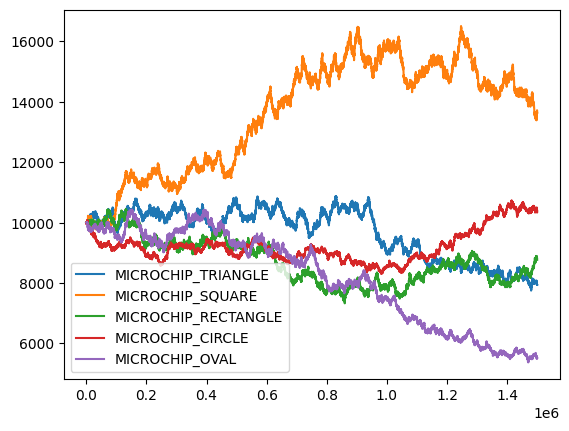

In [8]:
for p in chips:
    plt.plot(chip_prices[chip_prices['product'] == p]['mid_price'], label=p)
plt.legend()
plt.show()

Circle - Oval

Square - Rectangle

In [9]:
mids = chip_prices.pivot_table(
    index="timestamp",
    columns="product",
    values="mid_price",
).sort_index()

<Axes: title={'center': 'Average mid across all PEBBLES'}, xlabel='timestamp'>

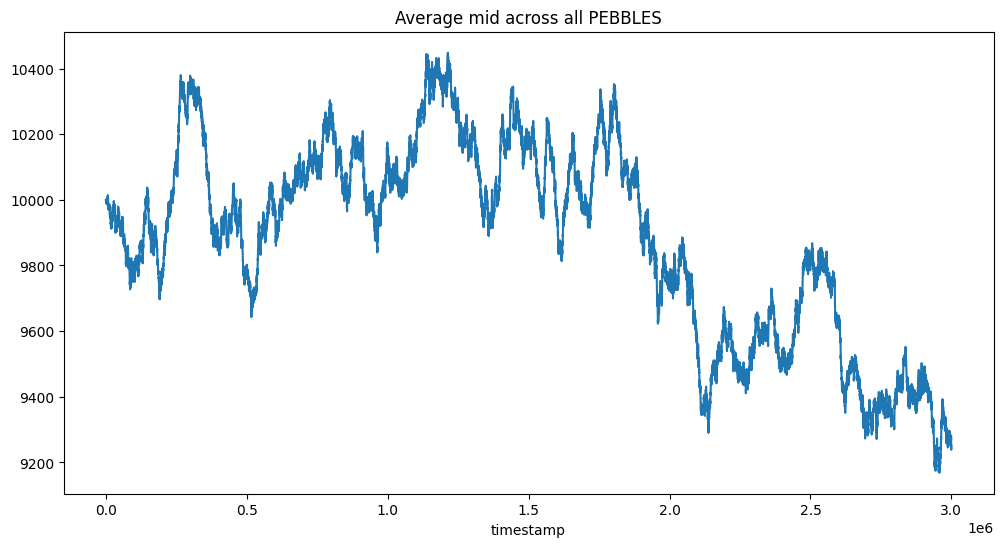

In [11]:
pebble_cols = [c for c in mids.columns]
mids["PEBBLES_avg"] = mids[pebble_cols].mean(axis=1)

mids["PEBBLES_avg"].plot(figsize=(12, 6), title="Average mid across all PEBBLES")